Learning Genetic Algorithms

End Case:
- Use GAs to optimize linkages to git a given criteria

# GA Overview

1. Start with a population of candidate solutions 
2. Evaluate the solutions 
3. Repeat the following steps over multiple generations:
    - Mutation: Randomly alter parts of a solution 
    - Crossover: Combine two solutions to create new solutions 
    - Selection: Keep the best solutions and discard the rest 

In [13]:
import random
import matplotlib.pyplot as plt

# Genetic Algorithm In Python Super Basic Example
https://www.youtube.com/watch?v=4XZoVQOt-0I&ab_channel=TheBuilder


In [14]:
def foo(x, y, z): 
    # The situation we are trying to solve for
    #error function
    return (6*x**3 + 9*y**2 + 90*z) - (25)


def fitness(x, y, z):
    # Fitness/Reward function, how good is our answer?

    ans = foo(x, y, z)
    if ans == 0:
        return 99999
    else:
        return abs(1/ans) #smaller number good

# generate solutions
solutions = []
for s in range(1000):
    solutions.append((random.uniform(0, 1000),
                    random.uniform(0, 1000),
                    random.uniform(0, 1000)))

print(solutions)

[(810.606612521429, 507.0597790786961, 393.68359093105875), (859.4381206144427, 577.1740974154081, 150.01211694798178), (134.66032845986254, 141.4174944520884, 730.6080327366378), (65.78682940816472, 558.711217656537, 319.3015930731793), (709.6910971327867, 56.85881302072726, 159.22234074144492), (655.7155141352281, 315.36120936778144, 400.86049336293183), (630.9077496892942, 927.5043439461969, 940.4181353898585), (912.9525160516181, 261.59625081890016, 475.9787738380583), (252.06104947614926, 413.28767910185695, 505.99073679471076), (586.6431951828428, 859.5127840706124, 587.9406428380942), (457.36485077037037, 321.65602433226616, 573.1551989120611), (414.78560698600467, 983.3916302431875, 145.64285727361525), (957.2834808428281, 723.6533385749015, 430.2011684147059), (451.001954444059, 780.471967102303, 314.8708388263196), (146.775587831248, 949.7368128058329, 779.3211411576721), (30.674484429210167, 831.2812748753679, 809.6156642617211), (432.07640471439936, 619.8148105759038, 625.2

In [15]:
gen_set = {
    "iterations":10000,
    "generations":1000,
    "mut":2,
    "exit_score":999
}

In [16]:
best_per_gen = []
for i in range(gen_set["iterations"]):
    # Calculate fitness of all solutions & rank best
    ranked_solutions = []
    for s in solutions:
        ranked_solutions.append((fitness(s[0],s[1], s[2]),s))
    ranked_solutions.sort()
    ranked_solutions.reverse()

    best_per_gen.append(ranked_solutions[0])
    
    if i % 100 == 0:
        print(f"==== Gen {i} best solution ====")
        print(ranked_solutions[0])

    #exit condition
    if ranked_solutions[0][0] > gen_set["exit_score"]:
        print(f"==== Gen {i} Success ====")
        print(ranked_solutions[0])
        best_answer = ranked_solutions[0]
        break

    #Gen part
    best_solns = ranked_solutions[:100] #top 100 best solutions
    elements_x = []
    elements_y = []
    elements_z = []
    #if complete black box, then sample from a unified "elements"
    for s in best_solns:
        elements_x.append(s[1][0])
        elements_y.append(s[1][1])
        elements_z.append(s[1][2])

    newGen = []
    for _ in range(gen_set["generations"]):
        e1 = random.choice(elements_x) * random.uniform(1-gen_set["mut"]/2, 1+gen_set["mut"]/2)
        e2 = random.choice(elements_y) * random.uniform(1-gen_set["mut"]/2, 1+gen_set["mut"]/2)
        e3 = random.choice(elements_z) * random.uniform(1-gen_set["mut"]/2, 1+gen_set["mut"]/2)

        newGen.append((e1, e2, e3))
    
    solutions = newGen

==== Gen 0 best solution ====
(1.2718428688935859e-05, (9.468685398236865, 3.3282015235421847, 816.1980631178175))
==== Gen 22 Success ====
(1556.3160581048783, (0.011875896641429714, 2.046356745570239e-05, 0.27778480543998796))


In [17]:
6*best_answer[1][0]**3 + 9*best_answer[1][1]**2 + 90*best_answer[1][2]

25.000642543007118

In [18]:
print(best_per_gen[-1])

(1556.3160581048783, (0.011875896641429714, 2.046356745570239e-05, 0.27778480543998796))


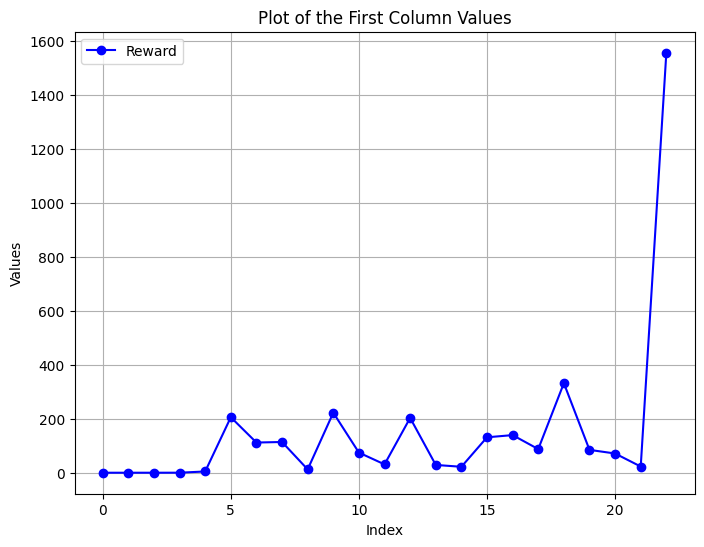

In [19]:
# print(best_per_gen)

# Extracting the first column (first elements of each tuple)
first_column = [item[0] for item in best_per_gen]

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(first_column, marker='o', linestyle='-', color='b', label='Reward')
plt.title("Plot of the First Column Values")
plt.xlabel("Index")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.show()

# GA using Mutation, X-Over, Selection

In [34]:
def fitness(solution):
    """Function we are solving for, higher fitness result is better"""
    x1, x2, x3 = solution
    result = x1**2 + x2 -x3 - 2

    if result == 0:
        return 9999
    else:
        return abs(1 / result) #closer to zero is better

In [35]:
def create_population(size, limits):
    """Create a population of size n, with limits"""
    return [
        tuple(random.uniform(lower, upper) for lower, upper in limits)
        for _ in range(size)
    ]

def select(population, fitness):
    """Roulette Wheel selection"""
    total_fitness = sum(fitness)
    probabilities = [f / total_fitness for f in fitness]
    return random.choices(population, weights=probabilities, k=2) # get 2 parent solutions

def crossover(parent1, parent2, limits):
    """Single crossover to create children for more diversity"""
    crossover_point = random.randint(1, len(parent1)-1)
    child1 = list(parent1[:crossover_point] + parent2[crossover_point:])
    child2 = list(parent2[:crossover_point] + parent1[crossover_point:])

    # Limit check children
    for i, (lower, upper) in enumerate(limits):
        child1[i] = max(lower, min(upper, child1[i]))
        child2[i] = max(lower, min(upper, child2[i]))
    
    return tuple(child1), tuple(child2)

def mutate(solution, limits, mutation_rate=0.1, mutation_scale=0.1):
    """chance to mutate each value in solution by a gaussian distribution"""
    mutated = list(solution)
    for i in range(len(solution)):
        if random.random() < mutation_rate:
            lower, upper = limits[i]
            range_size = upper - lower
            perturbation = random.gauss(0, mutation_scale * range_size)
            mutated[i] = max(lower, min(upper, mutated[i] + perturbation)) #clip bounds
    return tuple(mutated)


In [36]:
def plot_graph(fitness_per_gen):

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(fitness_per_gen, marker='o', linestyle='-', color='b', label='Reward')
    plt.title("Max Fitness over Gens")
    plt.xlabel("Generation")
    plt.ylabel("Top Fitness Score")
    plt.legend()
    plt.grid(True)
    plt.show()

In [37]:
def genetic_algorithm(sett):
    pop_size = sett["pop_size"]
    generations = sett["gens"]
    limits = sett["limits"]

    top_fitness = []
    population = create_population(pop_size, limits)

    for generation in range(generations):
        #evaluate population
        fitnesses = [fitness(ind) for ind in population]

        # Print the best solution in this generation
        best_solution = max(population, key=fitness)
        top_fitness.append(fitness(best_solution))
        print(f"Generation {generation}: Best solution = {best_solution}, Fitness = {fitness(best_solution)}")

        # Create the next generation
        new_population = []
        while len(new_population) < pop_size:
            # Selection
            parent1, parent2 = select(population, fitnesses)
            # Crossover
            child1, child2 = crossover(parent1, parent2, limits)
            # Mutation
            child1 = mutate(child1, limits, sett["mutation_rate"], sett["mutation_scale"])
            child2 = mutate(child2, limits, sett["mutation_rate"], sett["mutation_scale"])
            new_population.extend([child1, child2])
        
        # Update the population
        population = new_population[:pop_size]
    
    # Final best solution
    plot_graph(top_fitness)
    best_solution = max(population, key=fitness)
    return best_solution, fitness(best_solution)

Generation 0: Best solution = (2.36611968555082, 3.8519870865012753, 7.508924390076842), Fitness = 17.118909092678972
Generation 1: Best solution = (2.36611968555082, 3.9216951163387694, 7.508924390076842), Fitness = 88.54970328017473
Generation 2: Best solution = (2.36611968555082, 3.9216951163387694, 7.508924390076842), Fitness = 88.54970328017473
Generation 3: Best solution = (2.36611968555082, 3.9216951163387694, 7.508924390076842), Fitness = 88.54970328017473
Generation 4: Best solution = (2.36611968555082, 3.9216951163387694, 7.508924390076842), Fitness = 88.54970328017473
Generation 5: Best solution = (2.36611968555082, 3.9216951163387694, 7.508924390076842), Fitness = 88.54970328017473
Generation 6: Best solution = (2.3336811010308667, 4.065654711625276, 7.508924390076842), Fitness = 357.4233250466913
Generation 7: Best solution = (2.3336811010308667, 4.065654711625276, 7.508924390076842), Fitness = 357.4233250466913
Generation 8: Best solution = (2.3336811010308667, 4.06565471

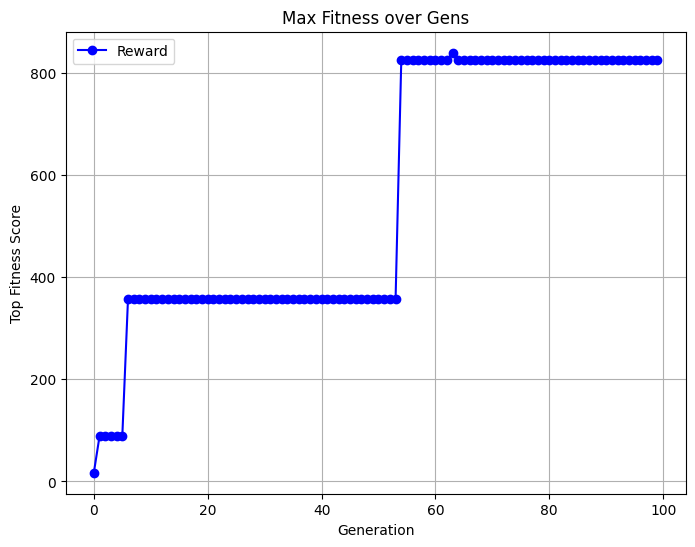

(2.3336811010308667, 4.061644932388855, 7.508924390076842) 825.0985885859471


In [38]:
settings = {
        "pop_size":30,
        "gens":100,
        "limits":[(1, 3), #x1
                (2, 5), #x2
                (1, 20)], #x3
        "mutation_rate":0.1,
        "mutation_scale":0.1
}

best, best_fitness = genetic_algorithm(settings)
print(best, best_fitness)